In [1]:
#F0484 Melbourne Housing Market - Price
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

filename = 'MELBOURNE_HOUSE_PRICES_LESS.csv'
df = pd.read_csv(filename)
df.head(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Postcode,Regionname,Propertycount,Distance,CouncilArea
0,Abbotsford,49 Lithgow St,3,h,1490000.0,S,Jellis,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
1,Abbotsford,59A Turner St,3,h,1220000.0,S,Marshall,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
2,Abbotsford,119B Yarra St,3,h,1420000.0,S,Nelson,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
3,Aberfeldie,68 Vida St,3,h,1515000.0,S,Barry,1/04/2017,3040,Western Metropolitan,1543,7.5,Moonee Valley City Council
4,Airport West,92 Clydesdale Rd,2,h,670000.0,S,Nelson,1/04/2017,3042,Western Metropolitan,3464,10.4,Moonee Valley City Council


In [2]:
#a
categorical_col = df.select_dtypes(include=['object']).columns.tolist()
numeric_col = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_col.remove('Postcode')
categorical_col.append('Postcode')

print(f"\nCategorical Features ({len(categorical_col)}):")
print(categorical_col)

print(f"\n\nNumeric Features ({len(numeric_col)}):")
print(numeric_col)


Categorical Features (9):
['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'Regionname', 'CouncilArea', 'Postcode']


Numeric Features (4):
['Rooms', 'Price', 'Propertycount', 'Distance']


In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 10000)
def summarize_numeric(df_num):
    rows = []
    total = len(df_num)
    for col in df_num.columns:
        s = df_num[col]
        n_nonnull = s.notna().sum()
        miss_pct = 100 * (1 - n_nonnull / total)
        card = s.nunique(dropna=True)
        rows.append({
            "column": col,
            "N": total,
            "% missing": round(miss_pct, 2),
            "cardinality": card,
            "min": s.min(),
            "Q1": s.quantile(0.25),
            "median": s.median(),
            "Q3": s.quantile(0.75),
            "max": s.max(),
            "mean": s.mean(),
            #"mode": s.mode().iloc[0] if not s.mode().empty else None,
            "std": s.std()
        })
    return pd.DataFrame(rows)

num_summary = summarize_numeric(df[numeric_col]) #C
print(num_summary)

          column      N  % missing  cardinality      min        Q1    median         Q3         max           mean            std
0          Rooms  63023       0.00           14      1.0       3.0       3.0        4.0        31.0       3.110595       0.957551
1          Price  63023      23.15         3417  85000.0  620000.0  830000.0  1220000.0  11200000.0  997898.241488  593498.919037
2  Propertycount  63023       0.00          368     39.0    4380.0    6795.0    10412.0     21650.0    7617.728131    4424.423167
3       Distance  63023       0.00          180      0.0       7.0      11.4       16.7        64.1      12.684829       7.592015


In [4]:
def summarize_categorical(df_cat):
    rows = []
    total = len(df_cat)
    for col in df_cat.columns:
        s = df_cat[col].astype("object")
        n_nonnull = s.notna().sum()
        miss_pct = 100 * (1 - n_nonnull / total)
        card = s.nunique(dropna=True)
        vc = s.value_counts(dropna=True) #value_counts - counts occurences of values
        mode1, mode2 = (vc.index[0] if len(vc) > 0 else np.nan,
                        vc.index[1] if len(vc) > 1 else np.nan)
        rows.append({
            "column": col,
            "N": total,
            "% missing": round(miss_pct, 2),
            "cardinality": card,
            "mode": mode1,
            "mode freq": int(vc.iloc[0]) if len(vc) > 0 else np.nan, #iloc - to get position in dataframe
            "mode %": round(100 * vc.iloc[0] / total, 2) if len(vc) > 0 else np.nan,
            "mode 2": mode2,
            "mode 2 freq": int(vc.iloc[1]) if len(vc) > 1 else np.nan,
            "mode 2 %": round(100 * vc.iloc[1] / total, 2) if len(vc) > 1 else np.nan
        })
    return pd.DataFrame(rows)

cat_summary = summarize_categorical(df[categorical_col])
print(cat_summary)

        column      N  % missing  cardinality                     mode  mode freq  mode %                 mode 2  mode 2 freq  mode 2 %
0       Suburb  63023        0.0          380                Reservoir       1241    1.97         Bentleigh East          845      1.34
1      Address  63023        0.0        57754          14 Northcote St          7    0.01           5 Charles St            7      0.01
2         Type  63023        0.0            3                        h      45053   71.49                      u        11655     18.49
3       Method  63023        0.0            9                        S      34063   54.05                     PI         9790     15.53
4      SellerG  63023        0.0          476                    Barry       6894   10.94                 Jellis         5499      8.73
5         Date  63023        0.0          112               24/03/2018       1144    1.82             28/10/2017         1119      1.78
6   Regionname  63023        0.0            8   

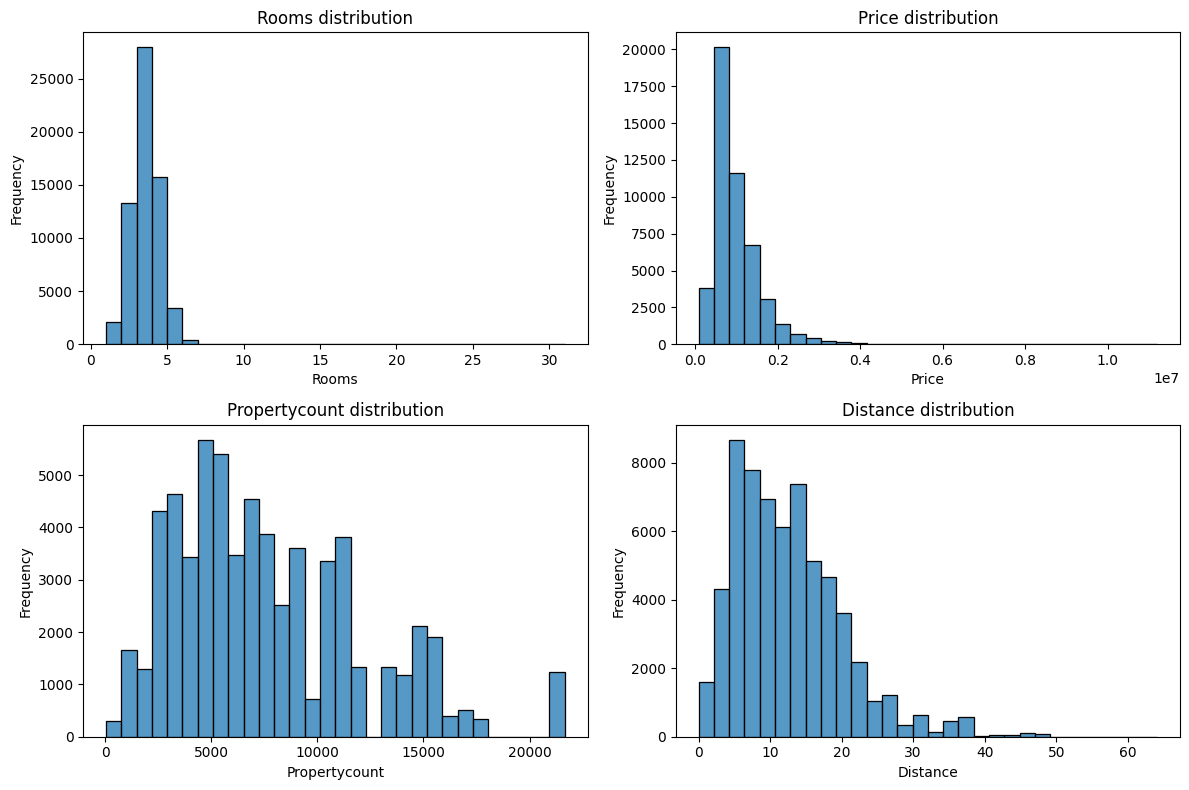

In [5]:
#b
columns_to_plot = ['Rooms', 'Price', 'Propertycount', 'Distance']
n_cols = 2
n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    sns.histplot(data=df, x=col, bins=30, ax=axes[i])
    axes[i].set_title(f'{col} distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Everything is right skewed, but column propertycount has less expressed tail

In [6]:
# 1. Duplicate rows
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 2


d,e. Identify relationships between variables using visualization tools

In [7]:
# 2. Data type problems
df['Postcode'] = df['Postcode'].astype('category')

In [ ]:
# 3. Missing target values
df_model = df.dropna(subset=['Price']).copy()

In [9]:
# 4. Outliers
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[
    (df['Price'] < lower) |
    (df['Price'] > upper)
]
print("Lower bound:", lower)
print("Upper bound:", upper)
print("Number of outliers:", len(outliers))

Lower bound: -280000.0
Upper bound: 2120000.0
Number of outliers: 2272


In [10]:
# 5. High-cardinality categorical variables
df_model = df_model.drop(columns=[
    'Address',
    'Suburb',
    'SellerG',
    'Postcode',
    'CouncilArea'
])

In [11]:
# 6. Invalid values
print("Price <= 0:", (df['Price'] <= 0).sum())
print("Rooms <= 0:", (df['Rooms'] <= 0).sum())
print("Distance < 0:", (df['Distance'] < 0).sum())
print("Propertycount < 0:", (df['Propertycount'] < 0).sum())

Price <= 0: 0
Rooms <= 0: 0
Distance < 0: 0
Propertycount < 0: 0


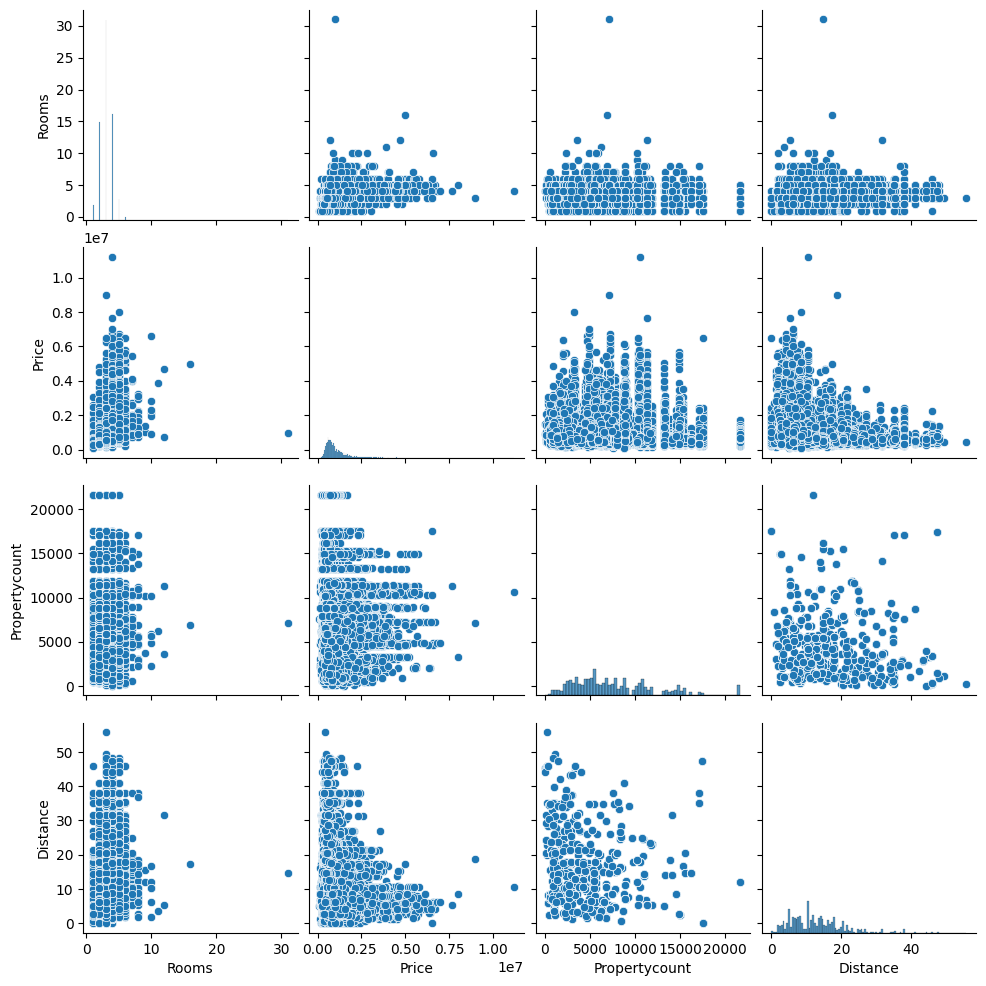

In [12]:
#splom
continuous_col = ['Rooms', 'Price', 'Propertycount', 'Distance']
sns.pairplot(df_model[continuous_col].dropna(), diag_kind='hist')
plt.show()

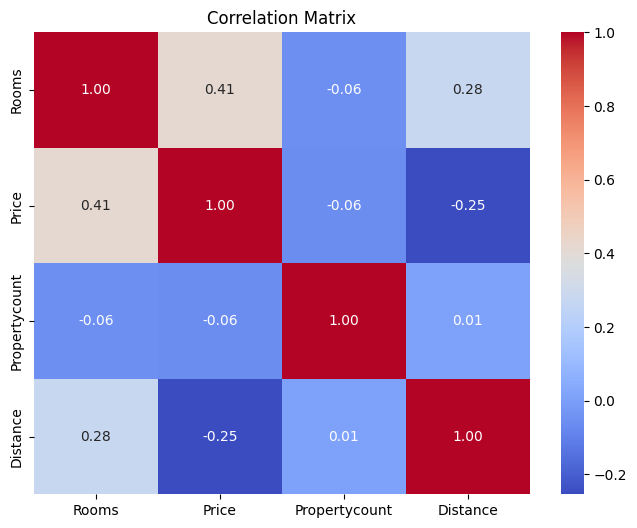

In [13]:
#correlation heatmap - works as well for task e
corr = df_model[continuous_col].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [35]:
import scipy.stats as stats

continuous_cols = ['Rooms', 'Propertycount', 'Distance', 'Price']
price_corr = df_model[continuous_cols].corr()['Price'].sort_values(ascending=False)
print("Pearson correlation coefficients")
print(price_corr.round(4))

corr_details = []
for col in ['Rooms', 'Propertycount', 'Distance']:
    valid_data = df_model[[col, 'Price']].dropna()
    r, p_val = stats.pearsonr(valid_data[col], valid_data['Price'])
    corr_details.append({
        'Feature': col,
        'Pearson r': round(r, 4),
        'p-value': p_val,
        'Statistically Significant (p < 0.05)': p_val < 0.05
    })

corr_df = pd.DataFrame(corr_details)
print("\nPearson significance test")
print(corr_df.to_string(index=False))

Pearson correlation coefficients
Price            1.0000
Rooms            0.4124
Propertycount   -0.0608
Distance        -0.2537
Name: Price, dtype: float64

Pearson significance test
      Feature  Pearson r      p-value  Statistically Significant (p < 0.05)
        Rooms     0.4124 0.000000e+00                                  True
Propertycount    -0.0608 7.332001e-41                                  True
     Distance    -0.2537 0.000000e+00                                  True


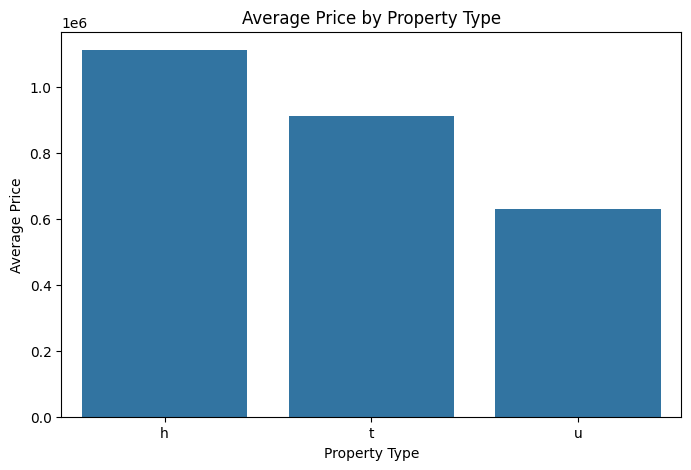

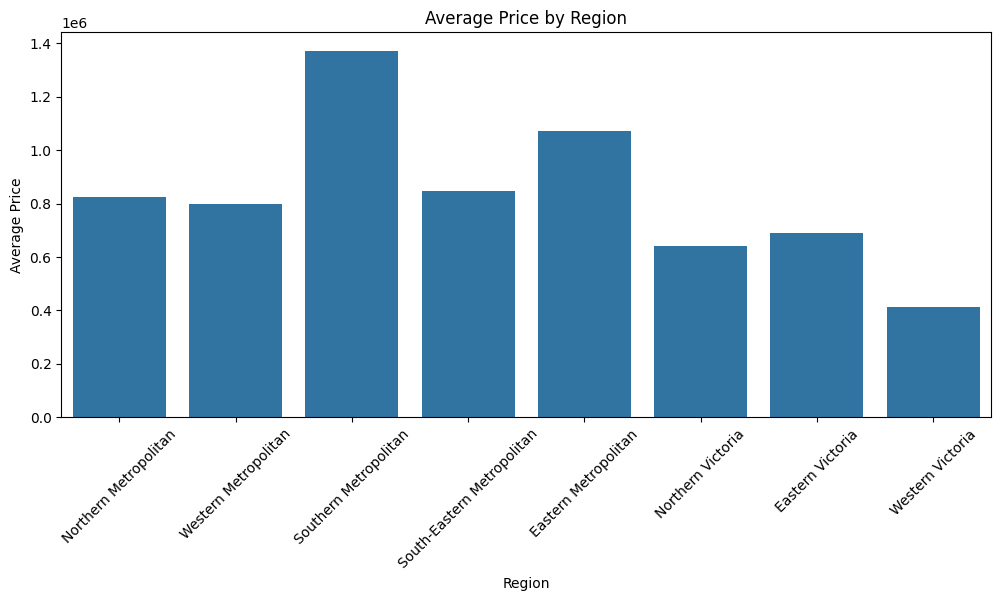

In [15]:
#bar plots
plt.figure(figsize=(8, 5))
sns.barplot(data=df_model, x='Type', y='Price', estimator='mean', errorbar=None)
plt.title('Average Price by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Average Price')
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=df_model, x='Regionname', y='Price', estimator='mean', errorbar=None)
plt.title('Average Price by Region')
plt.xlabel('Region')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

In [16]:
print(categorical_col)

['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'Regionname', 'CouncilArea', 'Postcode']


In [17]:
#f
split_index = int(0.8*len(df_model)) #split test and training data 80/20
train_df = df_model.iloc[:split_index].copy()
test_df = df_model.iloc[split_index:].copy()

In [ ]:
# Derived variables
rooms_mean = train_df['Rooms'].mean()
distance_mean = train_df['Distance'].mean()

train_df['Rooms_squared'] = (train_df['Rooms'] - rooms_mean) ** 2
test_df['Rooms_squared'] = (test_df['Rooms'] - rooms_mean) ** 2
train_df['Distance_squared'] = (train_df['Distance'] - distance_mean) ** 2
test_df['Distance_squared'] = (test_df['Distance'] - distance_mean) ** 2
train_df['Date'] = pd.to_datetime(train_df['Date'], dayfirst=True)
test_df['Date'] = pd.to_datetime(test_df['Date'], dayfirst=True)
train_df['Year'] = train_df['Date'].dt.year
train_df['Month'] = train_df['Date'].dt.month
test_df['Year'] = test_df['Date'].dt.year
test_df['Month'] = test_df['Date'].dt.month

train_df = train_df.drop(columns=['Date'])
test_df = test_df.drop(columns=['Date'])

In [ ]:
scale_features = ['Propertycount', 'Rooms_squared', 'Distance_squared', 'Rooms','Distance', 'Year', 'Month']
train_medians = train_df[scale_features].median()
train_df[scale_features] = train_df[scale_features].fillna(train_medians)
test_df[scale_features] = test_df[scale_features].fillna(train_medians)

train_means = train_df[scale_features].mean()
train_stds = train_df[scale_features].std()
train_df[scale_features] = (train_df[scale_features] - train_means)/train_stds
test_df[scale_features] = (test_df[scale_features] - train_means)/train_stds

one_hot_col = ['Type', 'Method','Regionname']
train_modes = train_df[one_hot_col].mode().iloc[0]
train_df[one_hot_col] = train_df[one_hot_col].fillna(train_modes)
test_df[one_hot_col] = test_df[one_hot_col].fillna(train_modes)
train_df = pd.get_dummies(train_df, columns=one_hot_col, drop_first=True)
test_df = pd.get_dummies(test_df, columns=one_hot_col, drop_first=True)
test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

X_train = train_df.drop(columns='Price') #separate x and y
y_train = train_df['Price']
X_test = test_df.drop(columns='Price')
y_test = test_df['Price']

In [20]:
#check
train_df.head(5)

,Rooms,Price,Propertycount,Distance,Rooms_squared,Distance_squared,Year,Month,Type_t,Type_u,Method_S,Method_SA,Method_SP,Method_VB,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria
0,-0.070265,1490000.0,-0.795889,-1.281515,-0.539282,0.320635,-0.0913,-0.914295,False,False,True,False,False,False,False,True,False,False,False,False,False
1,-0.070265,1220000.0,-0.795889,-1.281515,-0.539282,0.320635,-0.0913,-0.914295,False,False,True,False,False,False,False,True,False,False,False,False,False
2,-0.070265,1420000.0,-0.795889,-1.281515,-0.539282,0.320635,-0.0913,-0.914295,False,False,True,False,False,False,False,True,False,False,False,False,False
3,-0.070265,1515000.0,-1.348297,-0.684274,-0.539282,-0.265442,-0.0913,-0.914295,False,False,True,False,False,False,False,False,False,False,False,True,False
4,-1.139144,670000.0,-0.919713,-0.299386,0.161331,-0.454436,-0.0913,-0.914295,False,False,True,False,False,False,False,False,False,False,False,True,False


3. Linear Regression Model

In [21]:
#a1
X_train_np = X_train.astype(float).to_numpy()
y_train_np = y_train.astype(float).to_numpy()
X_test_np = X_test.astype(float).to_numpy()
y_test_np = y_test.astype(float).to_numpy()

X_train_intercept = np.column_stack([np.ones(len(X_train_np)), X_train_np]) #adding intercept column b0
X_test_intercept = np.column_stack([np.ones(len(X_test_np)), X_test_np])

beta_ls = np.linalg.pinv(X_train_intercept.T @ X_train_intercept) @ X_train_intercept.T @ y_train_np

print("Least squares coefficients:")
print(beta_ls)

Least squares coefficients:
[ 1.16794625e+06  2.55262569e+05  8.74501256e+02 -3.42312716e+05
 -2.09771895e+04  1.09593117e+05  3.87206746e+04  1.22729683e+04
 -2.07925980e+05 -4.17867670e+05  5.01402195e+04 -7.38351831e+03
  1.87039588e+04  5.07921252e+04 -1.00310028e+05 -3.23755438e+05
 -2.16316061e+05  7.88191103e+04  2.33041676e+05 -4.00559652e+05
 -2.88972105e+05]


In [22]:
print(X_train[['Rooms', 'Distance', 'Propertycount', 'Rooms_squared', 'Distance_squared']].describe().T)

                    count          mean  std       min       25%       50%       75%        max
Rooms             38745.0 -5.795109e-17  1.0 -2.208022 -1.139144 -0.070265  0.998613   9.549640
Distance          38745.0  5.134907e-17  1.0 -1.679676 -0.750634 -0.166666  0.536751   4.704165
Propertycount     38745.0  6.290261e-17  1.0 -1.679385 -0.737659 -0.227418  0.630421   3.137675
Rooms_squared     38745.0 -5.575042e-17  1.0 -0.539282 -0.539282 -0.001488  0.161331  48.883520
Distance_squared  38745.0 -2.494098e-17  1.0 -0.499163 -0.454436 -0.265442  0.041877  10.547535


In [23]:
print(X_train.dtypes)

Rooms                                    float64
Propertycount                            float64
Distance                                 float64
Rooms_squared                            float64
Distance_squared                         float64
Year                                     float64
Month                                    float64
Type_t                                      bool
Type_u                                      bool
Method_S                                    bool
Method_SA                                   bool
Method_SP                                   bool
Method_VB                                   bool
Regionname_Eastern Victoria                 bool
Regionname_Northern Metropolitan            bool
Regionname_Northern Victoria                bool
Regionname_South-Eastern Metropolitan       bool
Regionname_Southern Metropolitan            bool
Regionname_Western Metropolitan             bool
Regionname_Western Victoria                 bool
dtype: object


In [73]:
#a2
def fit_gradient_descent(X_inc, y, learning_rate=0.05, iterations=100000, tol=1e-9):
    y_mean, y_std = y.mean(), y.std() #scale for faster convergence
    y_scaled = (y - y_mean) / y_std
    
    n_samples, n_features = X_inc.shape
    beta_gd = np.zeros(n_features)
    previous_mse = np.inf
    loss_history = []
    
    for i in range(iterations):
        predictions = X_inc @ beta_gd #make predictions
        errors = predictions - y_scaled #calculate errors
        mse = np.mean(errors ** 2) #mse
        loss_history.append(mse)
        
        gradient = (2 / n_samples) * (X_inc.T @ errors) #gradient
        beta_gd -= learning_rate * gradient #update coeff
        
        if abs(previous_mse - mse) < tol: #check convergence
            break
        previous_mse = mse

    beta_original = beta_gd.copy() #rescale coeff back
    beta_original[1:] = beta_gd[1:] * y_std
    beta_original[0] = y_mean + y_std * beta_gd[0]
    
    return beta_original, i + 1, loss_history


In [74]:
beta_gd, iters, loss_history = fit_gradient_descent(X_train_intercept, y_train_np)
print("Initial MSE:", loss_history[0])
print("Final MSE:", loss_history[-1])
print("MSE reduction:", loss_history[0] - loss_history[-1])

Initial MSE: 0.9999999999999998
Final MSE: 0.4471530874555089
MSE reduction: 0.5528469125444908


In [75]:
print("Gradient descent coefficients:")
print(beta_gd)

Gradient descent coefficients:
[ 1.16744304e+06  2.55300739e+05  9.41285987e+02 -3.42464402e+05
 -2.09948954e+04  1.09273843e+05  3.87073123e+04  1.22712335e+04
 -2.07900986e+05 -4.17806421e+05  5.01525764e+04 -7.13318211e+03
  1.86804580e+04  5.08006834e+04 -9.65878219e+04 -3.23359432e+05
 -2.12889506e+05  7.99354000e+04  2.33382192e+05 -4.00139809e+05
 -2.76805756e+05]


In [76]:
coefficient_table = pd.DataFrame({'Variable': ['Intercept'] + X_train.columns.tolist(), 'Least Squares': beta_ls, 'Gradient Descent': beta_gd_original})
coefficient_table['Absolute Difference'] = (coefficient_table['Least Squares'] - coefficient_table['Gradient Descent']).abs()
print(coefficient_table.sort_values(by=['Absolute Difference']))

                                 Variable  Least Squares  Gradient Descent  Absolute Difference
7                                   Month   1.227297e+04      1.227123e+04             1.734755
13                              Method_VB   5.079213e+04      5.080068e+04             8.558267
10                               Method_S   5.014022e+04      5.015258e+04            12.356970
6                                    Year   3.872067e+04      3.870731e+04            13.362393
4                           Rooms_squared  -2.097719e+04     -2.099490e+04            17.705853
12                              Method_SP   1.870396e+04      1.868046e+04            23.500758
8                                  Type_t  -2.079260e+05     -2.079010e+05            24.993407
1                                   Rooms   2.552626e+05      2.553007e+05            38.170010
9                                  Type_u  -4.178677e+05     -4.178064e+05            61.248664
2                           Propertycoun

In [77]:
#3c
import scipy.stats as stats

n, k = X_train_intercept.shape
df_e = n - k  # degrees of freedom

# Residuals and residual variance sigma^2
residuals = y_train_np - (X_train_intercept @ beta_ls)
sigma2 = np.sum(residuals**2) / df_e

# Variance-covariance matrix of beta coefficients
var_beta = sigma2 * np.linalg.pinv(X_train_intercept.T @ X_train_intercept)
se_beta = np.sqrt(np.maximum(0, np.diag(var_beta)))

# t-statistics and 2-tailed p-values
t_stats = beta_ls / np.where(se_beta == 0, 1e-12, se_beta)
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=df_e))

# Summary table
feature_names = ['Intercept'] + list(X_train.columns)
hypothesis_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': beta_ls, 'Std_Err': se_beta, 't_stat': t_stats, 'p_value': p_values, 'Significant (p < 0.05)': p_values < 0.05})

print("Hypothesis testing")
print(hypothesis_df.to_string(index=False))

# Extract Significant Subsets for Subsequent Cross-Validation
sig_mask = hypothesis_df['Significant (p < 0.05)'].values[1:]
significant_cols = X_train.columns[sig_mask].tolist()

# Top 3 features by absolute t-stat magnitude (highest impact)
top_3_cols = hypothesis_df.iloc[1:].reindex(hypothesis_df.iloc[1:]['t_stat'].abs().sort_values(ascending=False).index).head(3)['Feature'].tolist()
print(f"\nTotal Input Features: {len(X_train.columns)}")
print(f"Significant Features Kept ({len(significant_cols)}): {significant_cols}")
print(f"Top 3 Significant Features: {top_3_cols}")

Hypothesis testing
                              Feature   Coefficient      Std_Err      t_stat      p_value  Significant (p < 0.05)
                            Intercept  1.167946e+06  7674.978844  152.175827 0.000000e+00                    True
                                Rooms  2.552626e+05  2668.704107   95.650383 0.000000e+00                    True
                        Propertycount  8.745013e+02  2110.230461    0.414410 6.785759e-01                   False
                             Distance -3.423127e+05  3115.202152 -109.884592 0.000000e+00                    True
                        Rooms_squared -2.097719e+04  2192.481200   -9.567785 0.000000e+00                    True
                     Distance_squared  1.095931e+05  2869.461304   38.192924 0.000000e+00                    True
                                 Year  3.872067e+04  2230.241465   17.361651 0.000000e+00                    True
                                Month  1.227297e+04  2207.689562    5

In [78]:
X_train_sig = X_train[significant_cols].values.astype(float) #only significant columns
X_test_sig = X_test[significant_cols].values.astype(float)

X_train_sig_inc = np.hstack([np.ones((len(X_train_sig), 1)), X_train_sig]) #add intercept column back
X_test_sig_inc = np.hstack([np.ones((len(X_test_sig), 1)), X_test_sig])
#use ols on significant features
beta_modified = np.linalg.pinv(X_train_sig_inc.T @ X_train_sig_inc) @ X_train_sig_inc.T @ y_train_np 

full_features = ['Intercept'] + list(X_train.columns)
df_beta_full = pd.DataFrame({'Feature': full_features, 'Beta_Full': beta_ls})
ref_features = ['Intercept'] + significant_cols
df_beta_ref = pd.DataFrame({'Feature': ref_features, 'Beta_Refined': beta_modified})

# Merge tables to inspect coefficient shifts
comparison_df = pd.merge(df_beta_full, df_beta_ref, on='Feature', how='left')
comparison_df['Beta_Refined'] = comparison_df['Beta_Refined'].fillna(0.0)
comparison_df['Absolute_Shift'] = (comparison_df['Beta_Full'] - comparison_df['Beta_Refined']).abs()

print("Coefficient comparison")
print(comparison_df.sort_values(by='Absolute_Shift', ascending=False).to_string(index=False))

Coefficient comparison
                              Feature     Beta_Full  Beta_Refined  Absolute_Shift
                            Method_SA -7.383518e+03  0.000000e+00     7383.518306
         Regionname_Northern Victoria -2.163161e+05 -2.172814e+05      965.316239
                        Propertycount  8.745013e+02  0.000000e+00      874.501256
          Regionname_Western Victoria -2.889721e+05 -2.898376e+05      865.457157
                            Intercept  1.167946e+06  1.167348e+06      598.332104
     Regionname_Northern Metropolitan -3.237554e+05 -3.231846e+05      570.885212
                             Method_S  5.014022e+04  5.053496e+04      394.735661
                            Method_SP  1.870396e+04  1.907504e+04      371.081803
                            Method_VB  5.079213e+04  5.114576e+04      353.638953
Regionname_South-Eastern Metropolitan  7.881911e+04  7.858478e+04      234.325588
     Regionname_Southern Metropolitan  2.330417e+05  2.332351e+05      193.

In [79]:
def run_cross_validation(X_data, y_data, feature_sets, k_folds=5, seed=42):
    np.random.seed(seed)
    n_samples = len(X_data)
    
    #generate shuffled fold indices
    shuffled_indices = np.arange(n_samples)
    np.random.shuffle(shuffled_indices)
    folds = np.array_split(shuffled_indices, k_folds)
    
    cv_results = {name: {'RMSE': [], 'R2': []} for name in feature_sets}
    for name, cols in feature_sets.items():
        X_sub = X_data[cols].values.astype(float)
        y_sub = np.asarray(y_data, dtype=float)
        
        for i in range(k_folds):
            val_idx = folds[i]
            train_idx = np.hstack([folds[j] for j in range(k_folds) if j != i])
            
            X_tr, X_val = X_sub[train_idx], X_sub[val_idx]
            y_tr, y_val = y_sub[train_idx], y_sub[val_idx]

            X_tr_inc = np.hstack([np.ones((X_tr.shape[0], 1)), X_tr]) #add intercept column
            X_val_inc = np.hstack([np.ones((X_val.shape[0], 1)), X_val])
            
            beta_fold = np.linalg.pinv(X_tr_inc.T @ X_tr_inc) @ X_tr_inc.T @ y_tr #ols
            
            y_pred = X_val_inc @ beta_fold #predict
            rmse = np.sqrt(np.mean((y_val - y_pred) ** 2)) #evaluation
            ss_res = np.sum((y_val - y_pred) ** 2)
            ss_tot = np.sum((y_val - np.mean(y_val)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            
            cv_results[name]['RMSE'].append(rmse)
            cv_results[name]['R2'].append(r2)
            
    return cv_results

# Define Feature Configurations
feature_sets = {
    "Case 1: Refined model (18)": significant_cols,
    "Case 2: Top 3 model (3)": top_3_cols,
    "Case 3: Full model (20)": list(X_train.columns)
}

# Execute function
cv_results = run_cross_validation(X_train, y_train_np, feature_sets, k_folds=5)

5 fold cross validation results
                Model Case RMSE Mean ($) RMSE Std ($) R² Mean R² Std
Case 1: Refined model (18)   $393,191.20    $4,884.28  0.5524 0.0057
   Case 2: Top 3 model (3)   $475,505.79    $5,485.13  0.3454 0.0074
   Case 3: Full model (20)   $393,208.98    $4,896.01  0.5523 0.0057


C:\Users\dsunt\AppData\Local\Temp\ipykernel_32536\2069001162.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rmse_data, labels=box_labels, patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'), medianprops=dict(color='red', linewidth=2))


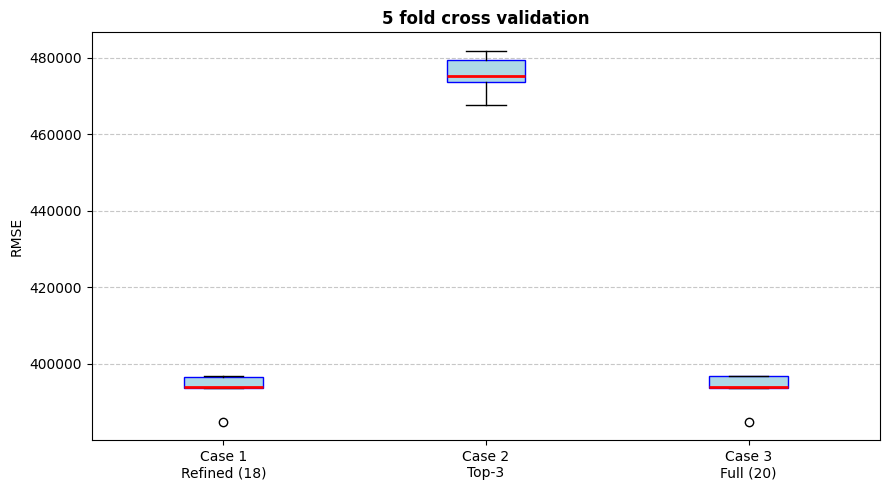

In [80]:
table_data = []
for name in feature_sets:
    rmse_mean = np.mean(cv_results[name]['RMSE'])
    rmse_std = np.std(cv_results[name]['RMSE'], ddof=1)
    r2_mean = np.mean(cv_results[name]['R2'])
    r2_std = np.std(cv_results[name]['R2'], ddof=1)
    table_data.append({'Model Case': name, 'RMSE Mean ($)': f"${rmse_mean:,.2f}", 'RMSE Std ($)': f"${rmse_std:,.2f}", 'R² Mean': f"{r2_mean:.4f}", 'R² Std': f"{r2_std:.4f}"})

summary_table = pd.DataFrame(table_data)

print("5 fold cross validation results")
print(summary_table.to_string(index=False))

plt.figure(figsize=(9, 5))
rmse_data = [cv_results[name]['RMSE'] for name in feature_sets]
box_labels = ["Case 1\nRefined (18)", "Case 2\nTop-3", "Case 3\nFull (20)"]

plt.boxplot(rmse_data, labels=box_labels, patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'), medianprops=dict(color='red', linewidth=2))

plt.title("5 fold cross validation", fontsize=12, fontweight='bold')
plt.ylabel("RMSE", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [96]:
#3f
#training and testing matrices with intercept
X_tr_sig = np.hstack([np.ones((len(X_train), 1)), X_train[significant_cols].values.astype(float)])
X_te_sig = np.hstack([np.ones((len(X_test), 1)), X_test[significant_cols].values.astype(float)])

y_tr_vec = np.asarray(y_train_np, dtype=float)
y_te_vec = np.asarray(y_test_np, dtype=float)

#fit OLS
beta_ols_final = np.linalg.pinv(X_tr_sig.T @ X_tr_sig) @ X_tr_sig.T @ y_tr_vec
y_pred_ols = X_te_sig @ beta_ols_final #predict
residuals_ols = y_te_vec - y_pred_ols

#fit grad 
beta_gd_3f, iters_3f, _ = fit_gradient_descent(X_tr_sig, y_tr_vec)
y_pred_gd = X_te_sig @ beta_gd_3f
residuals_gd = y_te_vec - y_pred_gd

def calculate_metrics(y_true, y_pred):
    res = y_true - y_pred
    mae = np.mean(np.abs(res))
    rmse = np.sqrt(np.mean(res**2))
    mape = np.mean(np.abs(res / y_true)) * 100
    
    ss_res = np.sum(res**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / ss_tot)
    return mae, rmse, mape, r2

mae_ols, rmse_ols, mape_ols, r2_ols = calculate_metrics(y_te_vec, y_pred_ols)
mae_gd, rmse_gd, mape_gd, r2_gd = calculate_metrics(y_te_vec, y_pred_gd)

print("Test set performance:")
print(f"Test MAE (OLS):  ${mae_ols:,.2f}")
print(f"Test RMSE (OLS): ${rmse_ols:,.2f}")
print(f"Test R² (OLS):   {r2_ols:.4f}")
print(f"Test MAE (GD):  ${mae_gd:,.2f}")
print(f"Test RMSE (GD): ${rmse_gd:,.2f}")
print(f"Test R² (GD):   {r2_gd:.4f}")

Test set performance:
Test MAE (OLS):  $268,023.11
Test RMSE (OLS): $424,864.84
Test R² (OLS):   0.5243
Test MAE (GD):  $268,021.69
Test RMSE (GD): $424,864.95
Test R² (GD):   0.5243


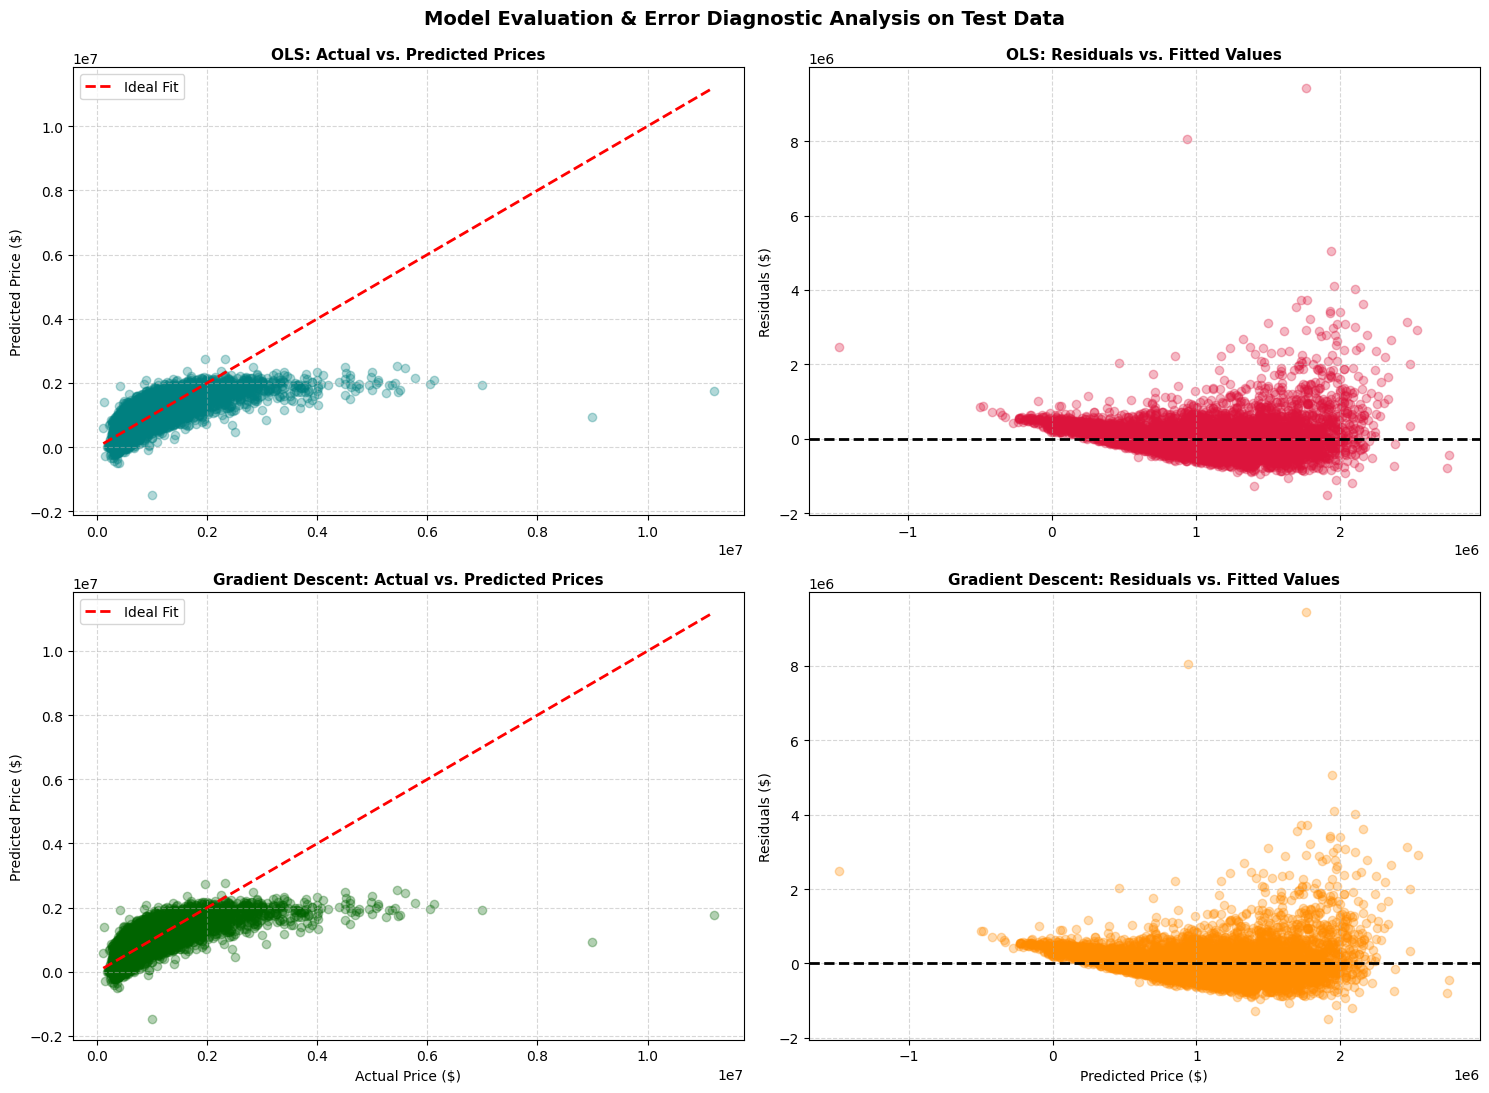

In [97]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
# Row 1: OLS Diagnostics
axes[0, 0].scatter(y_te_vec, y_pred_ols, alpha=0.3, color='teal')
axes[0, 0].plot([y_te_vec.min(), y_te_vec.max()], [y_te_vec.min(), y_te_vec.max()], 'r--', lw=2, label='Ideal Fit')
axes[0, 0].set_ylabel('Predicted Price ($)', fontsize=10)
axes[0, 0].set_title('OLS: Actual vs. Predicted Prices', fontsize=11, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

axes[0, 1].scatter(y_pred_ols, residuals_ols, alpha=0.3, color='crimson')
axes[0, 1].axhline(0, color='black', linestyle='--', lw=2)
axes[0, 1].set_ylabel('Residuals ($)', fontsize=10)
axes[0, 1].set_title('OLS: Residuals vs. Fitted Values', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# Row 2: Gradient Descent Diagnostics
axes[1, 0].scatter(y_te_vec, y_pred_gd, alpha=0.3, color='darkgreen')
axes[1, 0].plot([y_te_vec.min(), y_te_vec.max()], [y_te_vec.min(), y_te_vec.max()], 'r--', lw=2, label='Ideal Fit')
axes[1, 0].set_xlabel('Actual Price ($)', fontsize=10)
axes[1, 0].set_ylabel('Predicted Price ($)', fontsize=10)
axes[1, 0].set_title('Gradient Descent: Actual vs. Predicted Prices', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

axes[1, 1].scatter(y_pred_gd, residuals_gd, alpha=0.3, color='darkorange')
axes[1, 1].axhline(0, color='black', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted Price ($)', fontsize=10)
axes[1, 1].set_ylabel('Residuals ($)', fontsize=10)
axes[1, 1].set_title('Gradient Descent: Residuals vs. Fitted Values', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Model Evaluation & Error Diagnostic Analysis on Test Data", fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

In [112]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

X_tr_sk = X_train[significant_cols].values.astype(float)
X_te_sk = X_test[significant_cols].values.astype(float)
y_tr_sk = np.asarray(y_train_np, dtype=float).ravel()
y_te_sk = np.asarray(y_test_np, dtype=float).ravel()

sk_model = LinearRegression() #fit
sk_model.fit(X_tr_sk, y_tr_sk)

sk_preds = sk_model.predict(X_te_sk) #predictions and coefficients
sk_beta = np.insert(sk_model.coef_.ravel(), 0, sk_model.intercept_)

sk_mae = mean_absolute_error(y_te_sk, sk_preds) #error
sk_rmse = np.sqrt(mean_squared_error(y_te_sk, sk_preds))
sk_mape = np.mean(np.abs((y_te_sk - sk_preds) / y_te_sk)) * 100
custom_mape = np.mean(np.abs((y_te_vec.ravel() - y_pred_ols.ravel()) / y_te_vec.ravel())) * 100

print("Sklearn")
print(f"OLS Test MAE:   ${mae_ols:,.2f}    GD {mae_gd:,.2f}    Sklearn MAE:   ${sk_mae:,.2f}")
print(f"OLS Test RMSE:  ${rmse_ols:,.2f}    GD {rmse_gd:,.2f}    Sklearn RMSE:  ${sk_rmse:,.2f}")
print(f"OLS Test MAPE:  {custom_mape:.2f}%         GD {mape_gd:,.2f}         Sklearn MAPE:  {sk_mape:.2f}%")
coef_diff = [np.abs(beta_ols_final.ravel() - sk_beta), np.abs(beta_gd_3f.ravel() - sk_beta)]
print(f"Max Absolute Coefficient Difference: {np.max(coef_diff):.10e}")

Sklearn
OLS Test MAE:   $268,023.11    GD 268,021.69    Sklearn MAE:   $268,023.11
OLS Test RMSE:  $424,864.84    GD 424,864.95    Sklearn RMSE:  $424,864.84
OLS Test MAPE:  29.93%         GD 29.93         Sklearn MAPE:  29.93%
Max Absolute Coefficient Difference: 1.2101969693e+04


In [119]:
class MelbourneHousingPredictor:
    def __init__(self, beta_weights, feature_names, significant_cols, train_raw_df, scale_cols, one_hot_cols):
        self.beta = beta_weights
        self.feature_names = feature_names
        self.sig_cols = significant_cols
        self.scale_cols = scale_cols
        self.one_hot_cols = one_hot_cols
        
        self.rooms_mean = train_raw_df['Rooms'].mean()
        self.distance_mean = train_raw_df['Distance'].mean()
        engineered = train_raw_df.copy()
        engineered['Rooms_squared'] = (engineered['Rooms'] - self.rooms_mean) ** 2
        engineered['Distance_squared'] = (engineered['Distance'] - self.distance_mean) ** 2
        if 'Date' in engineered.columns:
            dates = pd.to_datetime(engineered['Date'], dayfirst=True)
            engineered['Year'] = dates.dt.year
            engineered['Month'] = dates.dt.month
        self.means = engineered[scale_cols].mean()
        self.stds = engineered[scale_cols].std()
        self.medians = engineered[scale_cols].median()

    def predict_single(self, raw_record: dict) -> float:
        df_in = pd.DataFrame([raw_record])
        df_in['Rooms_squared'] = (df_in['Rooms'] - self.rooms_mean) ** 2
        df_in['Distance_squared'] = (df_in['Distance'] - self.distance_mean) ** 2
        if 'Date' in df_in.columns and pd.notna(df_in['Date'].iloc[0]):
            date_dt = pd.to_datetime(df_in['Date'], dayfirst=True)
            df_in['Year'] = date_dt.dt.year
            df_in['Month'] = date_dt.dt.month
        else:
            df_in['Year'] = self.medians['Year']
            df_in['Month'] = self.medians['Month']
            
        df_in[self.scale_cols] = df_in[self.scale_cols].fillna(self.medians) #z-score
        df_in[self.scale_cols] = (df_in[self.scale_cols] - self.means) / self.stds
        
        df_encoded = pd.get_dummies(df_in, columns=self.one_hot_cols, drop_first=True) #one hot encoding
        df_aligned = df_encoded.reindex(columns=self.feature_names, fill_value=0)
        
        x_vec = np.insert(df_aligned[self.sig_cols].to_numpy().flatten().astype(float), 0, 1.0)
    
        predicted_price = float(x_vec @ self.beta)
        return predicted_price

predictor = MelbourneHousingPredictor(beta_weights=beta_gd_3f, feature_names=X_train.columns.tolist(), significant_cols=significant_cols, train_raw_df=df_model.iloc[:split_index], scale_cols=scale_features, one_hot_cols=one_hot_col)
sample_raw_record = {
    'Suburb': 'Abbotsford',
    'Rooms': 3,
    'Type': 'h',
    'Method': 'S',
    'SellerG': 'Biggin',
    'Date': '3/12/2016',
    'Distance': 2.5,
    'Postcode': 3067,
    'Propertycount': 4019,
    'Regionname': 'Northern Metropolitan'
}

predicted_val = predictor.predict_single(sample_raw_record)
print("Raw record:")
for key in sample_raw_record:
    print(f"\t{key}: {sample_raw_record[key]}")
print(f"Predicted Melbourne House Price: ${predicted_val:,.2f}")

Raw record:
	Suburb: Abbotsford
	Rooms: 3
	Type: h
	Method: S
	SellerG: Biggin
	Date: 3/12/2016
	Distance: 2.5
	Postcode: 3067
	Propertycount: 4019
	Regionname: Northern Metropolitan
Predicted Melbourne House Price: $1,632,094.09
